# Titanic Survival Analysis

## 1. Import Libraries and Load Data

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load the Titanic dataset
df = pd.read_csv('./titanic.csv')

print(f"Dataset shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
display(df.head())

Dataset shape: (887, 8)
Missing values: 0


,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


## 2. Data Overview and Basic Statistics

In [0]:
# Basic dataset information
print("=== DATASET INFO ===")
display(df.info())

print("\n=== SURVIVAL STATISTICS ===")
survival_stats = df['Survived'].value_counts()
survival_rate = df['Survived'].mean()
print(f"Overall Survival Rate: {survival_rate:.1%}")
print(f"Survivors: {survival_stats[1]} ({survival_stats[1]/len(df):.1%})")
print(f"Deaths: {survival_stats[0]} ({survival_stats[0]/len(df):.1%})")

print("\n=== NUMERICAL SUMMARY ===")
display(df.describe())

print("\n=== CATEGORICAL VARIABLES ===")
categorical_cols = ['Pclass', 'Sex']
for col in categorical_cols:
    print(f"\n{col}:")
    display(df[col].value_counts())

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Survived                 887 non-null    int64  
 1   Pclass                   887 non-null    int64  
 2   Name                     887 non-null    object 
 3   Sex                      887 non-null    object 
 4   Age                      887 non-null    float64
 5   Siblings/Spouses Aboard  887 non-null    int64  
 6   Parents/Children Aboard  887 non-null    int64  
 7   Fare                     887 non-null    float64
dtypes: float64(2), int64(4), object(2)
memory usage: 55.6+ KB


None


=== SURVIVAL STATISTICS ===
Overall Survival Rate: 38.6%
Survivors: 342 (38.6%)
Deaths: 545 (61.4%)

=== NUMERICAL SUMMARY ===


,Survived,Pclass,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
count,887.000000,887.000000,887.000000,887.000000,887.000000,887.00000
mean,0.385569,2.305524,29.471443,0.525366,0.383315,32.30542
std,0.487004,0.836662,14.121908,1.104669,0.807466,49.78204
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.00000
25%,0.000000,2.000000,20.250000,0.000000,0.000000,7.92500
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.45420
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.13750
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.32920



=== CATEGORICAL VARIABLES ===

Pclass:


Pclass
3    487
1    216
2    184
Name: count, dtype: int64


Sex:


Sex
male      573
female    314
Name: count, dtype: int64

## 3. Survival Analysis by Key Factors

=== SURVIVAL BY GENDER ===


,Total,Survivors,Survival_Rate
Sex,,,
female,314,233,0.742
male,573,109,0.190



=== SURVIVAL BY CLASS ===


,Total,Survivors,Survival_Rate
Pclass,,,
1,216,136,0.630
2,184,87,0.473
3,487,119,0.244


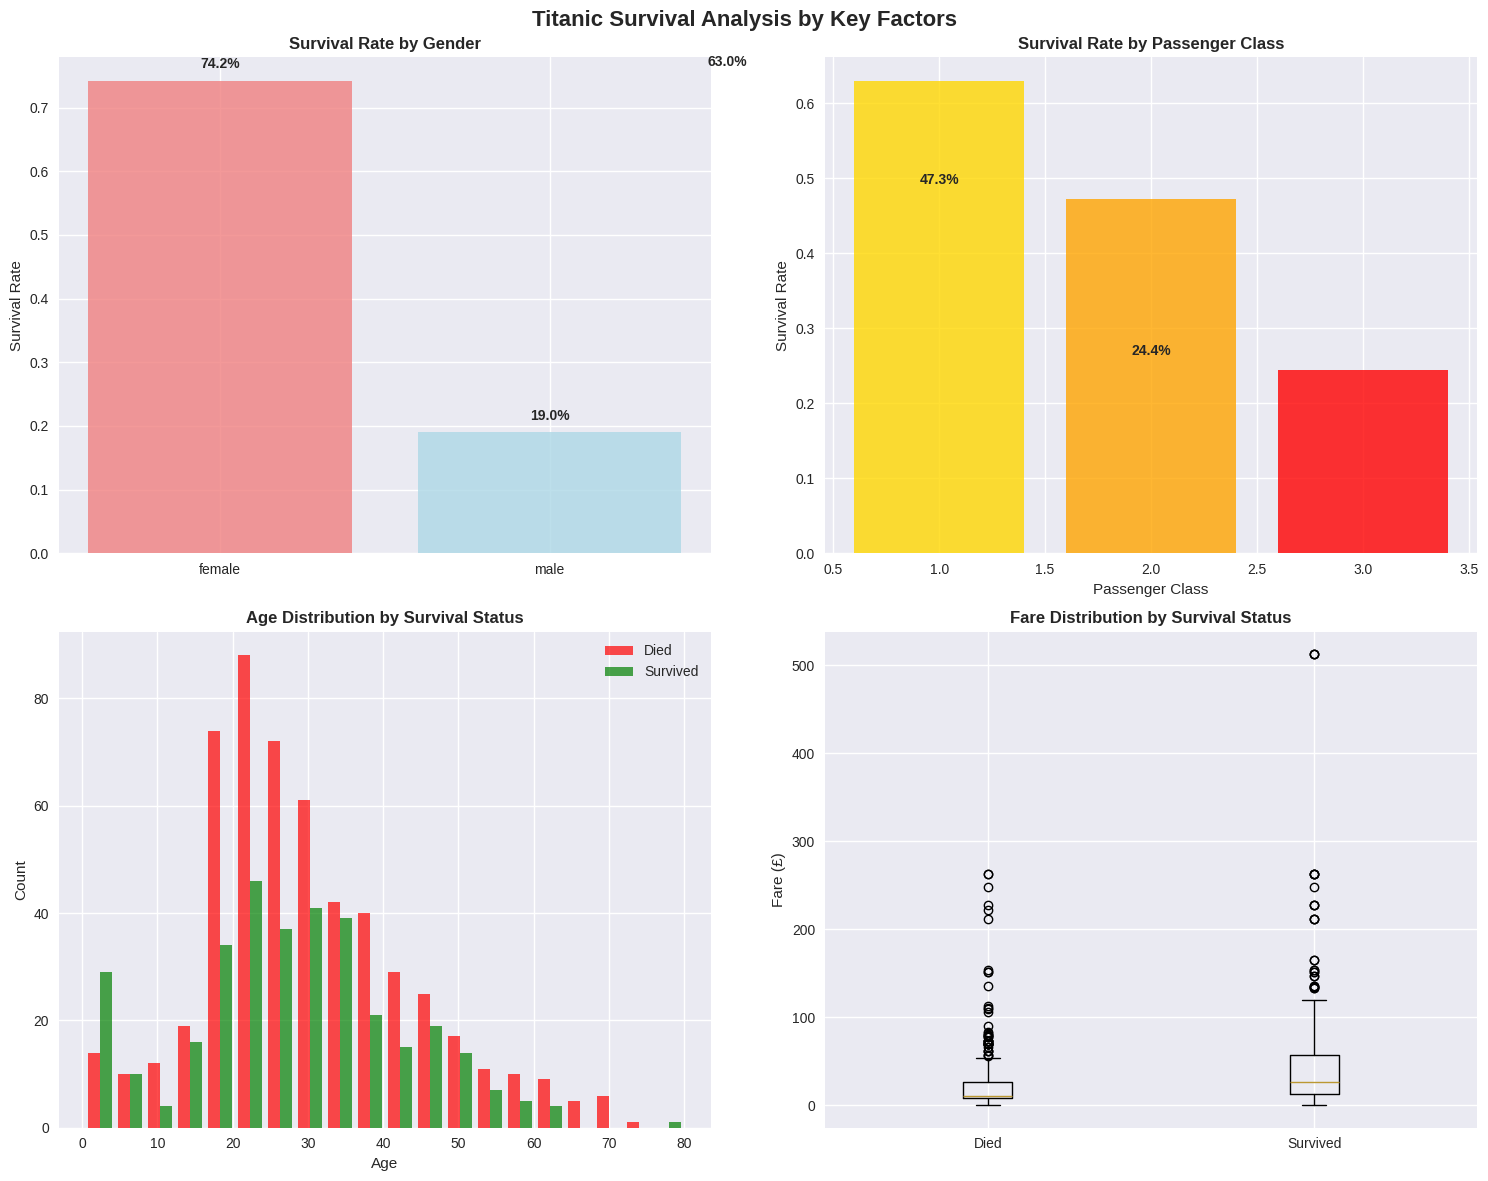

In [0]:
# Create comprehensive survival analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Titanic Survival Analysis by Key Factors', fontsize=16, fontweight='bold')

# 1. Survival by Gender
gender_survival = df.groupby('Sex')['Survived'].agg(['count', 'sum', 'mean']).round(3)
gender_survival.columns = ['Total', 'Survivors', 'Survival_Rate']
print("=== SURVIVAL BY GENDER ===")
display(gender_survival)

axes[0,0].bar(gender_survival.index, gender_survival['Survival_Rate'], 
              color=['lightcoral', 'lightblue'], alpha=0.8)
axes[0,0].set_title('Survival Rate by Gender', fontweight='bold')
axes[0,0].set_ylabel('Survival Rate')
for i, v in enumerate(gender_survival['Survival_Rate']):
    axes[0,0].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

# 2. Survival by Class
class_survival = df.groupby('Pclass')['Survived'].agg(['count', 'sum', 'mean']).round(3)
class_survival.columns = ['Total', 'Survivors', 'Survival_Rate']
print("\n=== SURVIVAL BY CLASS ===")
display(class_survival)

axes[0,1].bar(class_survival.index, class_survival['Survival_Rate'], 
              color=['gold', 'orange', 'red'], alpha=0.8)
axes[0,1].set_title('Survival Rate by Passenger Class', fontweight='bold')
axes[0,1].set_ylabel('Survival Rate')
axes[0,1].set_xlabel('Passenger Class')
for i, v in enumerate(class_survival['Survival_Rate']):
    axes[0,1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

# 3. Age Distribution by Survival
axes[1,0].hist([df[df['Survived']==0]['Age'], df[df['Survived']==1]['Age']], 
               bins=20, alpha=0.7, label=['Died', 'Survived'], color=['red', 'green'])
axes[1,0].set_title('Age Distribution by Survival Status', fontweight='bold')
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('Count')
axes[1,0].legend()

# 4. Fare Distribution by Survival
axes[1,1].boxplot([df[df['Survived']==0]['Fare'], df[df['Survived']==1]['Fare']], 
                  labels=['Died', 'Survived'])
axes[1,1].set_title('Fare Distribution by Survival Status', fontweight='bold')
axes[1,1].set_ylabel('Fare (£)')

plt.tight_layout()
plt.savefig('./outputs/survival_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Advanced Analysis: Family Size and Combined Factors

=== SURVIVAL BY FAMILY SIZE ===


,Total,Survivors,Survival_Rate
Family_Category,,,
Alone,533,163,0.306
Small Family,292,169,0.579
Large Family,62,10,0.161



=== SURVIVAL BY AGE CATEGORY ===


,Total,Survivors,Survival_Rate
Age_Category,,,
Child,79,43,0.544
Teen,87,35,0.402
Adult,695,259,0.373
Senior,26,5,0.192


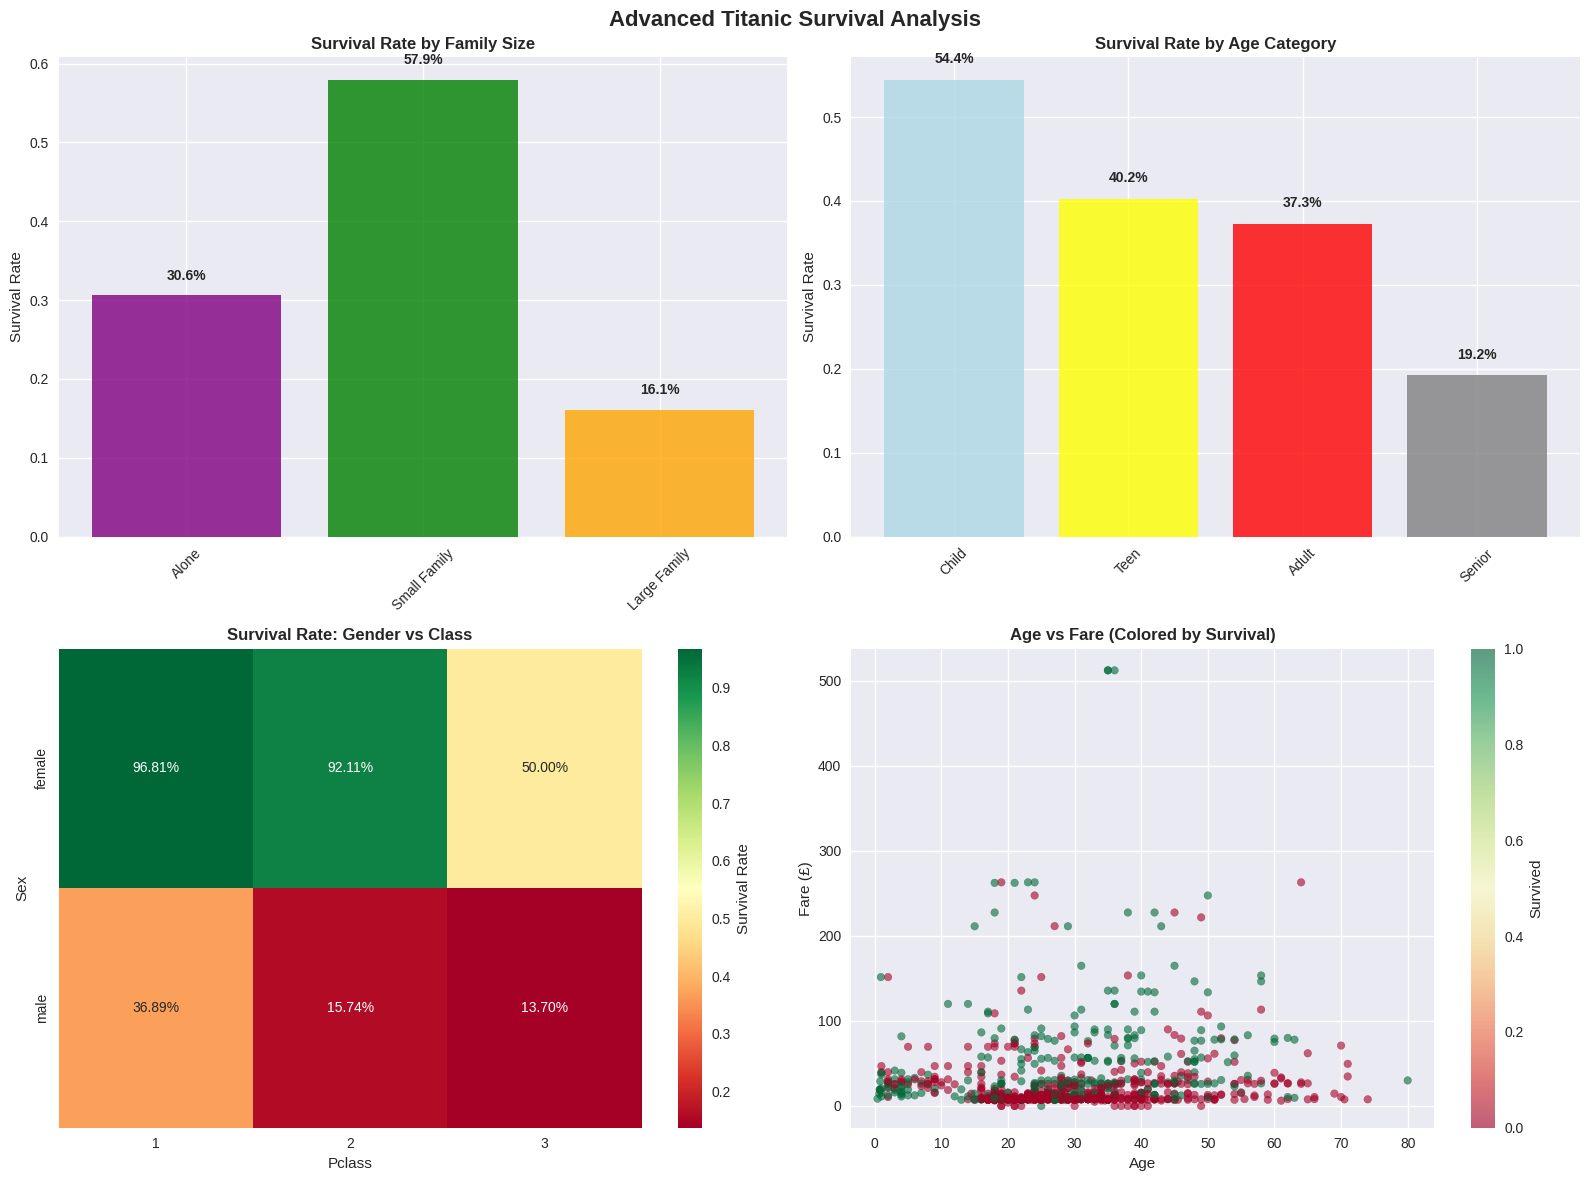

In [0]:
# Create family size feature
df['Family_Size'] = df['Siblings/Spouses Aboard'] + df['Parents/Children Aboard'] + 1
df['Family_Category'] = pd.cut(df['Family_Size'], 
                               bins=[0, 1, 4, 20], 
                               labels=['Alone', 'Small Family', 'Large Family'])

# Age categories
df['Age_Category'] = pd.cut(df['Age'], 
                           bins=[0, 12, 18, 60, 100], 
                           labels=['Child', 'Teen', 'Adult', 'Senior'])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Advanced Titanic Survival Analysis', fontsize=16, fontweight='bold')

# 1. Family Size Analysis
family_survival = df.groupby('Family_Category')['Survived'].agg(['count', 'sum', 'mean']).round(3)
family_survival.columns = ['Total', 'Survivors', 'Survival_Rate']
print("=== SURVIVAL BY FAMILY SIZE ===")
display(family_survival)

axes[0,0].bar(family_survival.index, family_survival['Survival_Rate'], 
              color=['purple', 'green', 'orange'], alpha=0.8)
axes[0,0].set_title('Survival Rate by Family Size', fontweight='bold')
axes[0,0].set_ylabel('Survival Rate')
axes[0,0].tick_params(axis='x', rotation=45)
for i, v in enumerate(family_survival['Survival_Rate']):
    axes[0,0].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

# 2. Age Category Analysis
age_survival = df.groupby('Age_Category')['Survived'].agg(['count', 'sum', 'mean']).round(3)
age_survival.columns = ['Total', 'Survivors', 'Survival_Rate']
print("\n=== SURVIVAL BY AGE CATEGORY ===")
display(age_survival)

axes[0,1].bar(age_survival.index, age_survival['Survival_Rate'], 
              color=['lightblue', 'yellow', 'red', 'gray'], alpha=0.8)
axes[0,1].set_title('Survival Rate by Age Category', fontweight='bold')
axes[0,1].set_ylabel('Survival Rate')
axes[0,1].tick_params(axis='x', rotation=45)
for i, v in enumerate(age_survival['Survival_Rate']):
    axes[0,1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

# 3. Heatmap: Gender vs Class Survival
survival_heatmap = df.pivot_table(values='Survived', index='Sex', columns='Pclass', aggfunc='mean')
sns.heatmap(survival_heatmap, annot=True, fmt='.2%', cmap='RdYlGn', 
            ax=axes[1,0], cbar_kws={'label': 'Survival Rate'})
axes[1,0].set_title('Survival Rate: Gender vs Class', fontweight='bold')

# 4. Scatter: Age vs Fare colored by Survival
scatter = axes[1,1].scatter(df['Age'], df['Fare'], c=df['Survived'], 
                           cmap='RdYlGn', alpha=0.6, s=30)
axes[1,1].set_title('Age vs Fare (Colored by Survival)', fontweight='bold')
axes[1,1].set_xlabel('Age')
axes[1,1].set_ylabel('Fare (£)')
plt.colorbar(scatter, ax=axes[1,1], label='Survived')

plt.tight_layout()
plt.savefig('./outputs/advanced_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Key Insights and Statistical Summary

In [0]:
# Statistical tests and key insights
from scipy.stats import chi2_contingency

print("🚢 TITANIC SURVIVAL ANALYSIS - KEY INSIGHTS")
print("=" * 60)

# Overall statistics
total_passengers = len(df)
survivors = df['Survived'].sum()
survival_rate = df['Survived'].mean()

print(f"📊 OVERALL STATISTICS:")
print(f"   • Total Passengers: {total_passengers:,}")
print(f"   • Survivors: {survivors:,} ({survival_rate:.1%})")
print(f"   • Deaths: {total_passengers - survivors:,} ({1-survival_rate:.1%})")

print(f"\n🔍 KEY FINDINGS:")

# Gender analysis
female_survival = df[df['Sex'] == 'female']['Survived'].mean()
male_survival = df[df['Sex'] == 'male']['Survived'].mean()
print(f"   • Women had {female_survival/male_survival:.1f}x higher survival rate than men")
print(f"     - Female survival: {female_survival:.1%}")
print(f"     - Male survival: {male_survival:.1%}")

# Class analysis
class_1_survival = df[df['Pclass'] == 1]['Survived'].mean()
class_3_survival = df[df['Pclass'] == 3]['Survived'].mean()
print(f"   • 1st class passengers had {class_1_survival/class_3_survival:.1f}x higher survival rate than 3rd class")
print(f"     - 1st Class: {class_1_survival:.1%}")
print(f"     - 3rd Class: {class_3_survival:.1%}")

# Age analysis
child_survival = df[df['Age_Category'] == 'Child']['Survived'].mean()
adult_survival = df[df['Age_Category'] == 'Adult']['Survived'].mean()
print(f"   • Children had {child_survival/adult_survival:.1f}x higher survival rate than adults")
print(f"     - Children (0-12): {child_survival:.1%}")
print(f"     - Adults (18-60): {adult_survival:.1%}")

# Family size analysis
small_family_survival = df[df['Family_Category'] == 'Small Family']['Survived'].mean()
alone_survival = df[df['Family_Category'] == 'Alone']['Survived'].mean()
print(f"   • Small families had {small_family_survival/alone_survival:.1f}x higher survival rate than solo travelers")
print(f"     - Small Family (2-4): {small_family_survival:.1%}")
print(f"     - Alone: {alone_survival:.1%}")

# Statistical significance tests
print(f"\n📈 STATISTICAL SIGNIFICANCE (Chi-square tests):")

# Gender vs Survival
chi2_gender, p_gender, _, _ = chi2_contingency(pd.crosstab(df['Sex'], df['Survived']))
print(f"   • Gender vs Survival: χ² = {chi2_gender:.2f}, p = {p_gender:.2e} {'✓ Significant' if p_gender < 0.05 else '✗ Not significant'}")

# Class vs Survival
chi2_class, p_class, _, _ = chi2_contingency(pd.crosstab(df['Pclass'], df['Survived']))
print(f"   • Class vs Survival: χ² = {chi2_class:.2f}, p = {p_class:.2e} {'✓ Significant' if p_class < 0.05 else '✗ Not significant'}")

# Create summary table
print(f"\n📋 SURVIVAL RATE SUMMARY TABLE:")
summary_data = {
    'Factor': ['Overall', 'Female', 'Male', '1st Class', '2nd Class', '3rd Class', 
               'Children', 'Teens', 'Adults', 'Seniors', 'Alone', 'Small Family', 'Large Family'],
    'Count': [len(df), len(df[df['Sex']=='female']), len(df[df['Sex']=='male']),
              len(df[df['Pclass']==1]), len(df[df['Pclass']==2]), len(df[df['Pclass']==3]),
              len(df[df['Age_Category']=='Child']), len(df[df['Age_Category']=='Teen']), 
              len(df[df['Age_Category']=='Adult']), len(df[df['Age_Category']=='Senior']),
              len(df[df['Family_Category']=='Alone']), len(df[df['Family_Category']=='Small Family']), 
              len(df[df['Family_Category']=='Large Family'])],
    'Survival_Rate': [df['Survived'].mean(), df[df['Sex']=='female']['Survived'].mean(), 
                      df[df['Sex']=='male']['Survived'].mean(), df[df['Pclass']==1]['Survived'].mean(),
                      df[df['Pclass']==2]['Survived'].mean(), df[df['Pclass']==3]['Survived'].mean(),
                      df[df['Age_Category']=='Child']['Survived'].mean(), df[df['Age_Category']=='Teen']['Survived'].mean(),
                      df[df['Age_Category']=='Adult']['Survived'].mean(), df[df['Age_Category']=='Senior']['Survived'].mean(),
                      df[df['Family_Category']=='Alone']['Survived'].mean(), df[df['Family_Category']=='Small Family']['Survived'].mean(),
                      df[df['Family_Category']=='Large Family']['Survived'].mean()]
}

summary_df = pd.DataFrame(summary_data)
summary_df['Survival_Rate'] = summary_df['Survival_Rate'].round(3)
summary_df = summary_df.sort_values('Survival_Rate', ascending=False)

display(summary_df)

# Save summary to file
summary_df.to_csv('./outputs/titanic_survival_summary.csv', index=False)
print(f"\n💾 Analysis saved to outputs folder!")
print(f"   • Charts: survival_analysis.png, advanced_analysis.png")
print(f"   • Data: titanic_survival_summary.csv")

🚢 TITANIC SURVIVAL ANALYSIS - KEY INSIGHTS
📊 OVERALL STATISTICS:
   • Total Passengers: 887
   • Survivors: 342 (38.6%)
   • Deaths: 545 (61.4%)

🔍 KEY FINDINGS:
   • Women had 3.9x higher survival rate than men
     - Female survival: 74.2%
     - Male survival: 19.0%
   • 1st class passengers had 2.6x higher survival rate than 3rd class
     - 1st Class: 63.0%
     - 3rd Class: 24.4%
   • Children had 1.5x higher survival rate than adults
     - Children (0-12): 54.4%
     - Adults (18-60): 37.3%
   • Small families had 1.9x higher survival rate than solo travelers
     - Small Family (2-4): 57.9%
     - Alone: 30.6%

📈 STATISTICAL SIGNIFICANCE (Chi-square tests):
   • Gender vs Survival: χ² = 258.39, p = 3.85e-58 ✓ Significant
   • Class vs Survival: χ² = 101.22, p = 1.05e-22 ✓ Significant

📋 SURVIVAL RATE SUMMARY TABLE:


,Factor,Count,Survival_Rate
1,Female,314,0.742
3,1st Class,216,0.630
11,Small Family,292,0.579
6,Children,79,0.544
4,2nd Class,184,0.473
7,Teens,87,0.402
0,Overall,887,0.386
8,Adults,695,0.373
10,Alone,533,0.306
5,3rd Class,487,0.244



💾 Analysis saved to outputs folder!
   • Charts: survival_analysis.png, advanced_analysis.png
   • Data: titanic_survival_summary.csv
